# Model B: DDR baseline (Differential Sharpe Ratio direct reinforcement)

Phase 2, Model B of the four-model comparison (B: DDR, C: TACR, D: fuzzy+transformer+offline RL).

**What this notebook does**
1. Trains the DDR policy on the offline market path (Phase-1 features, time-split train/val/test).
2. Shows training curves (DSR loss, EMA Sharpe, val realized Sharpe).
3. Evaluates on the TEST set with the regime breakdown (primary result; blended secondary).

**Offline adaptation (explicit)**: DDR here sees the OFFLINE state sequence (feature windows from
`features_regimes.parquet`) but generates its OWN actions; the DSR reward comes from those own
actions against the REALIZED next-day market returns. Logged behavior-policy actions/rewards are
never used. This is option (a) of the Phase-2 spec. (All four Phase-1 policies shared one market
path, so the buy_and_hold + momentum filter selects the full unique date sequence.)

In [1]:
import sys
from pathlib import Path

# notebooks/ or repo root depending on kernel cwd
root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [2]:
from src.models.ddr.config import DDRConfig
from src.models.ddr.train import train_ddr
from src.models.ddr.eval import evaluate

cfg = DDRConfig(epochs=30)  # same defaults as `python -m src.models.ddr.train`

In [3]:
model, history, checkpoint = train_ddr(cfg)
history

,epoch,train_loss,train_sharpe_ema,val_sharpe_ann
0,1,-0.003174,-1.252927,0.539477
1,2,0.000625,-1.228600,0.666230
2,3,0.001424,-1.262689,0.778296
3,4,0.001502,-1.302117,0.888229
4,5,0.001762,-1.318018,0.989201
5,6,0.002204,-1.294784,1.081247
6,7,0.002709,-1.233227,1.151253
7,8,0.003011,-1.145630,1.175776
8,9,0.002987,-1.050516,1.154068
9,10,0.002617,-0.953914,1.117059


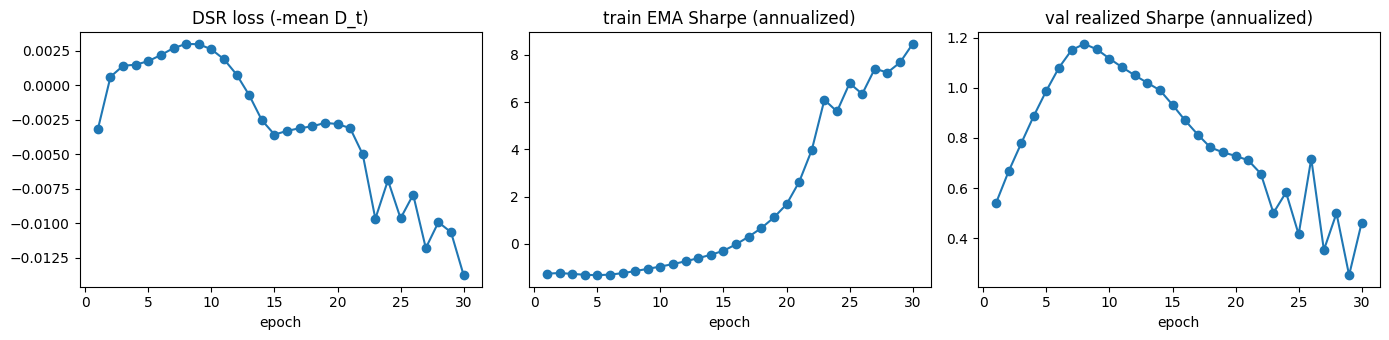

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(history["epoch"], history["train_loss"], marker="o")
axes[0].set_title("DSR loss (-mean D_t)")
axes[1].plot(history["epoch"], history["train_sharpe_ema"], marker="o")
axes[1].set_title("train EMA Sharpe (annualized)")
axes[2].plot(history["epoch"], history["val_sharpe_ann"], marker="o")
axes[2].set_title("val realized Sharpe (annualized)")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [5]:
preds, table = evaluate(cfg, checkpoint=checkpoint)
table

[eval] excluded 5 data-hole boundary day(s) from metrics


,n_days,cum_return,sharpe_annualized,max_drawdown,mean_daily_ret
bull,378,0.075736,0.836526,-0.060216,0.000200
bear,118,0.102737,1.669210,-0.058638,0.000862
crisis,20,0.012840,2.052939,-0.009318,0.000650
all,516,0.201486,1.130483,-0.083349,0.000369


## Reading the table

- **Per-regime rows are the PRIMARY result**; `all` (blended) is secondary.
- `max_drawdown` per regime is the within-regime sub-path drawdown (documented in `src/eval/regime_eval.py`).
- Regime labels are joined by date from Phase 1 (`features_regimes.parquet`) — never recomputed.
- Small-n regimes (crisis n=20 in the test window) have wide Sharpe error bars; treat them as noise-floor evidence, not point estimates.